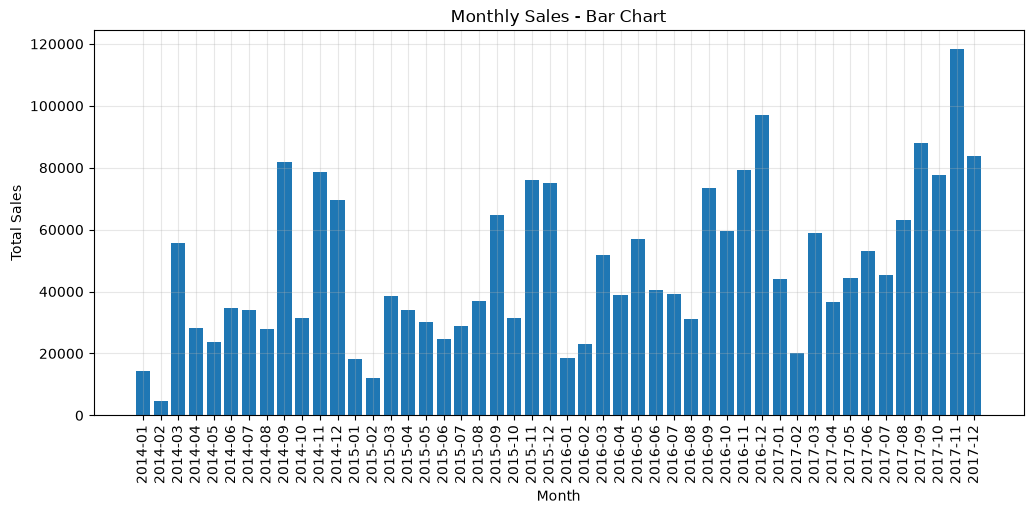

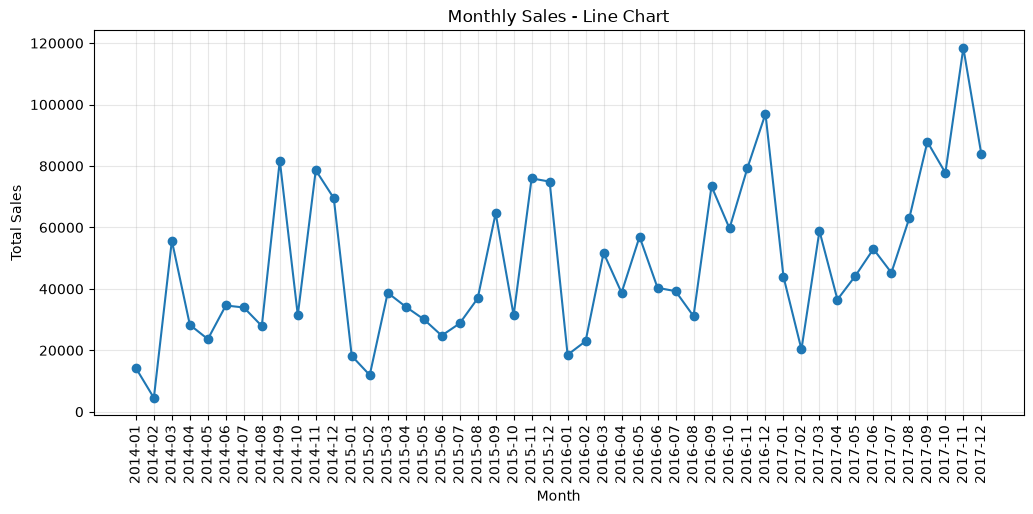

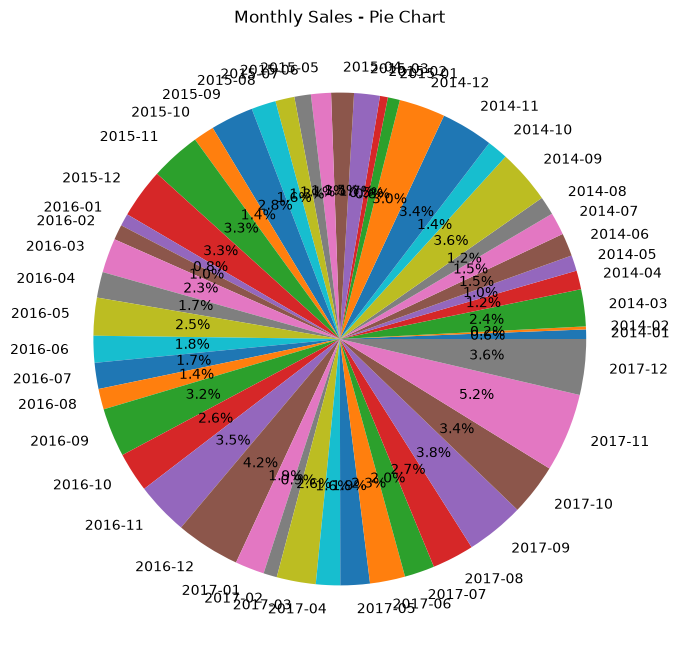

In [6]:
#task 01
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

months = monthly_sales.index.astype(str)
sales = monthly_sales.values

#BAR CHART
plt.figure(figsize=(12, 5))
plt.bar(months, sales)
plt.title("Monthly Sales - Bar Chart")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()


#LINE CHART 
plt.figure(figsize=(12, 5))
plt.plot(months, sales, marker="o")
plt.title("Monthly Sales - Line Chart")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()


#PIE CHART
plt.figure(figsize=(8, 8))
plt.pie(sales, labels=months, autopct="%1.1f%%")
plt.title("Monthly Sales - Pie Chart")
plt.show()

task 01
The same monthly sales data is shown using a bar chart, line chart, and pie chart. The line chart shows the trend best because it clearly shows increases and decreases over time. The pie chart hides the trend because it is better for showing parts of a whole.

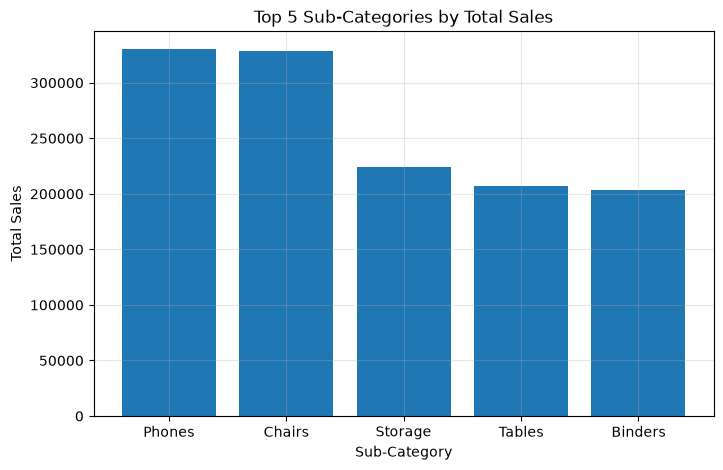

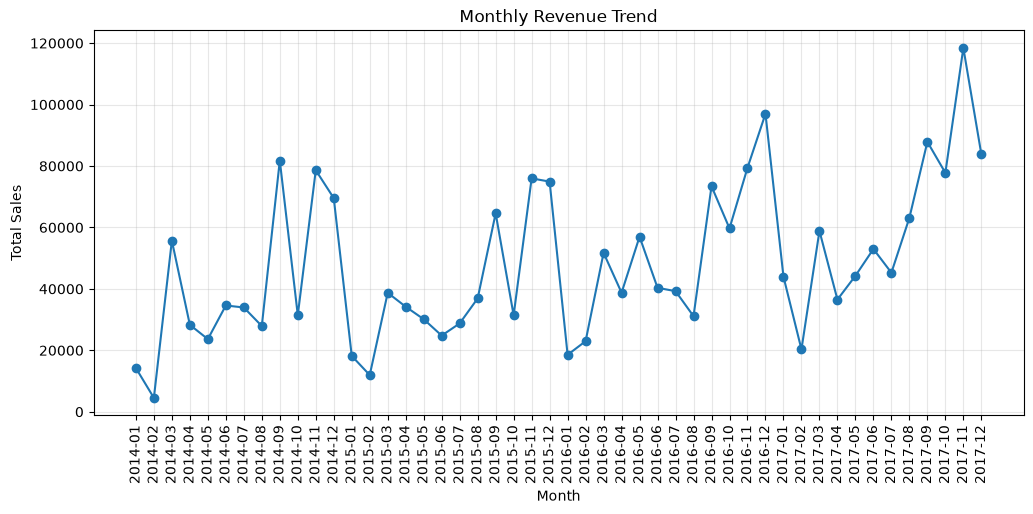

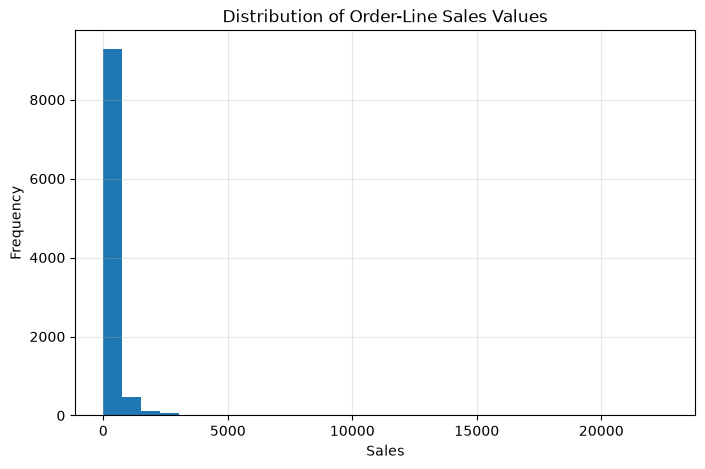

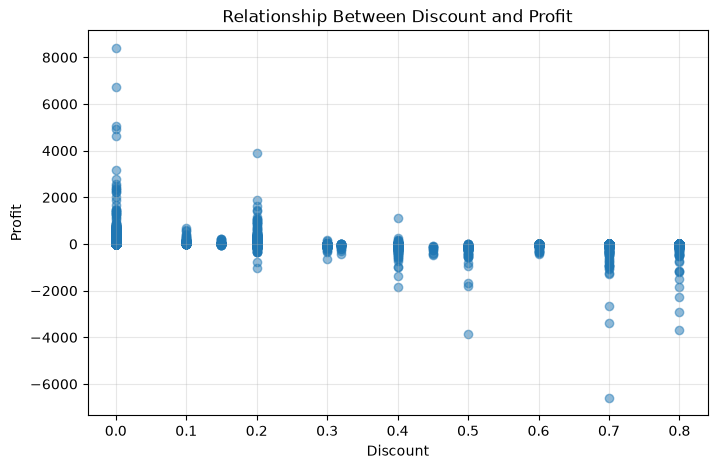

In [7]:
#task 02

subcategory_sales = df.groupby("Sub-Category")["Sales"].sum()
top5_subcategories = subcategory_sales.sort_values(ascending=False).head(5)

#Bar chart
plt.figure(figsize=(8, 5))
plt.bar(top5_subcategories.index, top5_subcategories.values)

plt.title("Top 5 Sub-Categories by Total Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.show()


monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M"))["Sales"].sum()

# Convert period to string
months = monthly_sales.index.astype(str)

#Line chart
plt.figure(figsize=(12, 5))
plt.plot(months, monthly_sales.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.show()

# Histogram 
plt.figure(figsize=(8, 5))

plt.hist(df["Sales"], bins=30)

plt.title("Distribution of Order-Line Sales Values")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

# Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

task 02
1. Top 5 Sub-Categories

A bar chart is used because it makes it easy to compare sales between different sub-categories. A pie chart would make exact comparisons harder.

2. Revenue Trend Over Time

A line chart is used because it clearly shows how sales change over time. It makes increases and decreases easy to see.

3. Distribution of Sales

A histogram is used because it shows how the sales values are distributed and how frequently different values occur.

4. Discount vs Profit

A scatter plot is used because it shows the relationship between discount and profit. It helps us see whether higher discounts are related to lower profit.

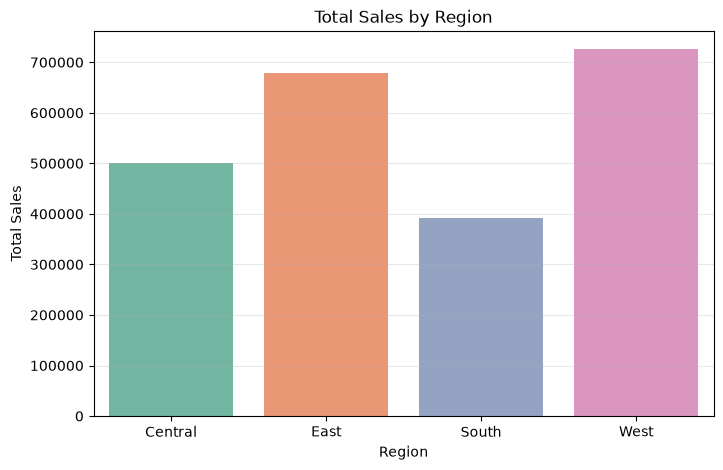

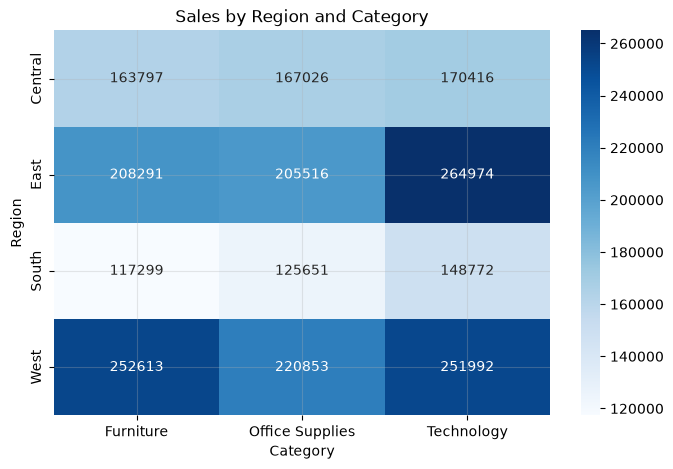

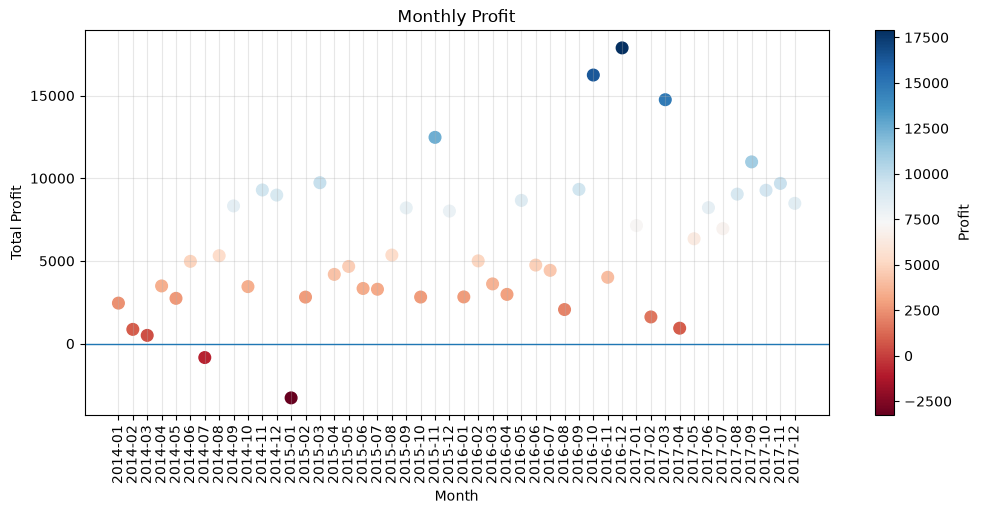

In [9]:
#task 03
import seaborn as sns

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    hue=region_sales.index,
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

region_category_sales = df.pivot_table(
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    region_category_sales,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")

plt.show()

monthly_profit = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Profit"].sum()

months = monthly_profit.index.astype(str)

plt.figure(figsize=(12, 5))

plt.scatter(
    months,
    monthly_profit.values,
    c=monthly_profit.values,
    cmap="RdBu",
    s=70
)

plt.axhline(0, linewidth=1)

plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.xticks(rotation=90)

plt.colorbar(label="Profit")

plt.show()

task 03
(a) Sales by Region

A categorical color palette is used because regions are different categories. Different colors make each region easy to identify.

(b) Region and Category Heatmap

A sequential color palette is used because different shades represent low to high sales values. Darker shades show higher sales.

(c) Monthly Profit

A diverging color palette is used because profit can be positive or negative. It helps distinguish profit from loss.

Blue 4.82 :1
PASS
Green 3.4 :1
FAIL
Orange 2.53 :1
FAIL
Purple 4.26 :1
FAIL


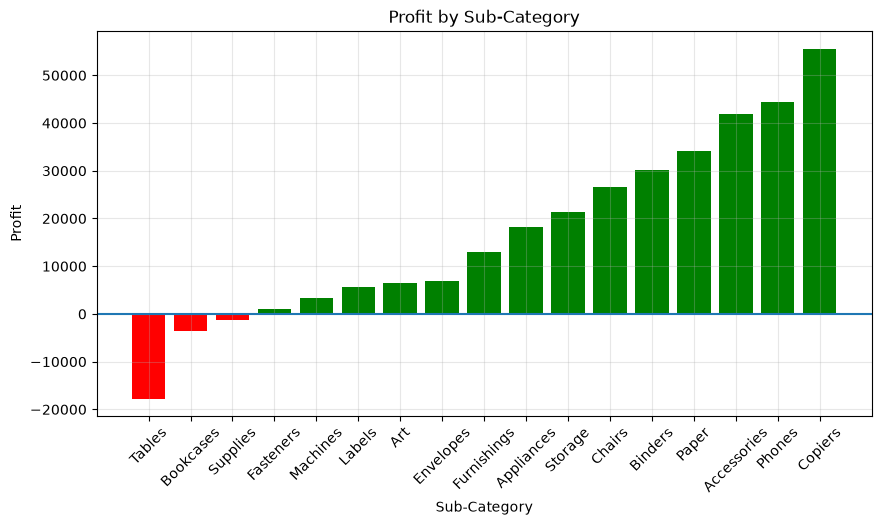

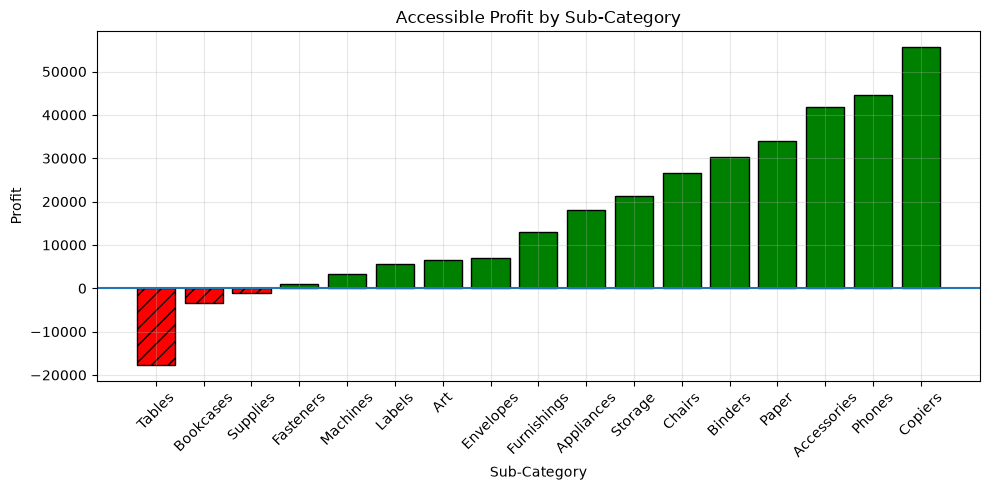

Alt text: Green bars show profit and red hatched bars show loss.


In [11]:
#task04
def contrast_ratio(color1, color2):
    def luminance(rgb):
        rgb = [x / 255 for x in rgb]

        for i in range(3):
            if rgb[i] <= 0.03928:
                rgb[i] = rgb[i] / 12.92
            else:
                rgb[i] = ((rgb[i] + 0.055) / 1.055) ** 2.4

        return 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]

    l1 = luminance(color1)
    l2 = luminance(color2)

    if l1 < l2:
        l1, l2 = l2, l1

    return (l1 + 0.05) / (l2 + 0.05)


colors = {
    "Blue": (31, 119, 180),
    "Green": (44, 160, 44),
    "Orange": (255, 127, 14),
    "Purple": (148, 103, 189)
}

for name, color in colors.items():
    ratio = contrast_ratio(color, (255, 255, 255))
    print(name, round(ratio, 2), ":1")

    if ratio >= 4.5:
        print("PASS")
    else:
        print("FAIL")


profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()


colors = ["red" if x < 0 else "green" for x in profit]

plt.figure(figsize=(10, 5))
plt.bar(profit.index, profit.values, color=colors)
plt.axhline(0)
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(10, 5))

for i, value in enumerate(profit):
    if value < 0:
        plt.bar(i, value, color="red", hatch="//", edgecolor="black")
    else:
        plt.bar(i, value, color="green", edgecolor="black")

plt.axhline(0)
plt.title("Accessible Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(range(len(profit)), profit.index, rotation=45)
plt.tight_layout()
plt.show()

print("Alt text: Green bars show profit and red hatched bars show loss.")

task04
Contrast Ratio

The contrast ratio is calculated to check whether the colors meet the WCAG AA 4.5:1 requirement. Colors below this ratio fail the required contrast level.

Red-Green Chart

The original chart uses only red and green to show loss and profit. This can be difficult for people with red-green color blindness.

Fixed Chart
Hatching is added to the loss bars so that loss and profit can be distinguished without depending only on color.

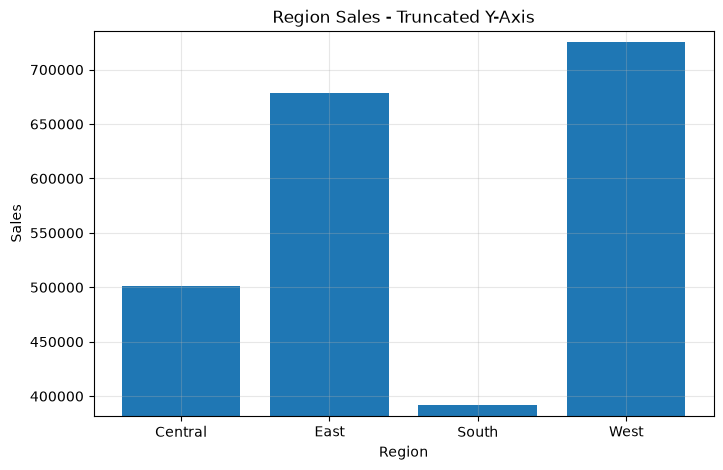

Caption: Truncated y-axis exaggerates the difference between regions.


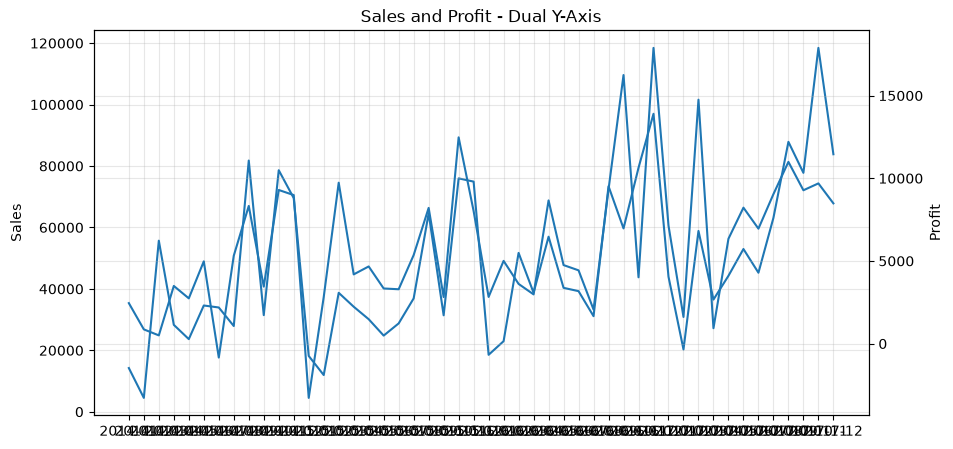

Caption: Dual y-axes can imply a relationship between two measures with different scales.


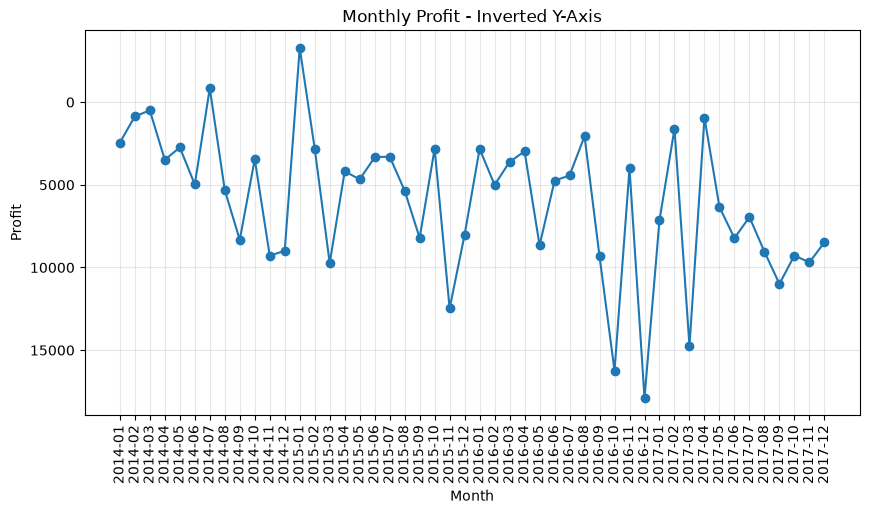

Caption: Inverting the y-axis can make a decline appear like growth.


In [14]:
#task 05
region_sales = df.groupby("Region")["Sales"].sum()


monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()


monthly_profit = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Profit"].sum()


#Truncated Y-Axis

plt.figure(figsize=(8, 5))

plt.bar(region_sales.index, region_sales.values)

plt.ylim(region_sales.min() - 10000, region_sales.max() + 10000)

plt.title("Region Sales - Truncated Y-Axis")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

print("Caption: Truncated y-axis exaggerates the difference between regions.")


#Dual Y-Axis

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

ax1.set_ylabel("Sales")

ax2 = ax1.twinx()

ax2.plot(
    monthly_profit.index.astype(str),
    monthly_profit.values
)

ax2.set_ylabel("Profit")

plt.title("Sales and Profit - Dual Y-Axis")

plt.xticks(rotation=90)

plt.show()

print("Caption: Dual y-axes can imply a relationship between two measures with different scales.")


#Inverted Y-Axis

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profit.index.astype(str),
    monthly_profit.values,
    marker="o"
)

plt.gca().invert_yaxis()

plt.title("Monthly Profit - Inverted Y-Axis")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=90)

plt.show()

print("Caption: Inverting the y-axis can make a decline appear like growth.")

task 05
Distortion: Truncated y-axis
Distortion: Dual y-axes
Distortion: Inverted y-axis

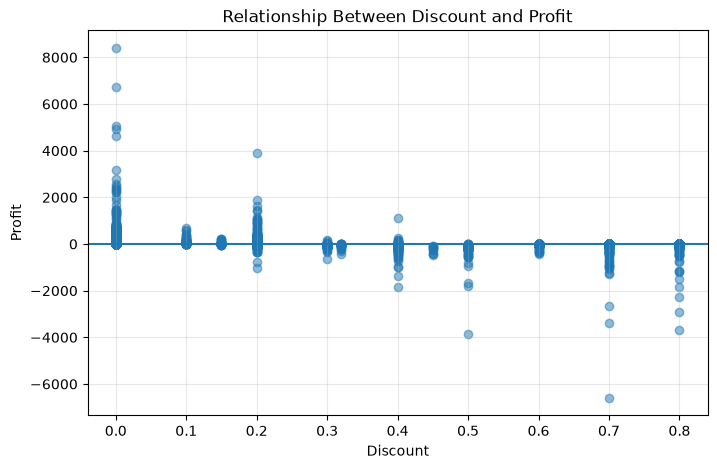

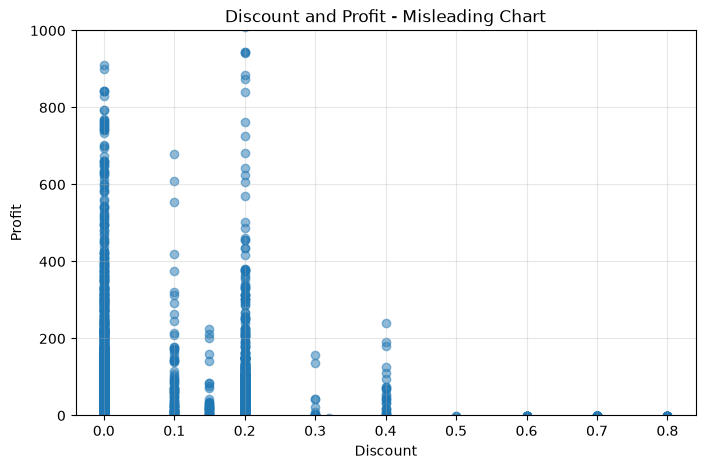

In [15]:
#task 06

# Honest chart
plt.figure(figsize=(8, 5))

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.axhline(0)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()


# Misleading chart
plt.figure(figsize=(8, 5))

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)

plt.ylim(0, 1000)

plt.title("Discount and Profit - Misleading Chart")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Honest Chart

A scatter plot is used because both discount and profit are numerical values. It shows their relationship clearly.

Misleading Chart

The misleading chart uses a restricted y-axis, which hides some values and gives a distorted view of the relationship.

Color and Accessibility

A simple color is used so the chart is easy to read. The chart does not depend on color alone to communicate the main information.